# Hongkong Horse Racing – Exploratory Data Analysis

This notebook provides an exploratory data analysis (EDA) of the Hongkong Horse Jockey Club dataset.  
It covers an initial overview, data quality checks, feature inspection, and basic preprocessing steps.  
The goal is to understand the structure, content, and potential issues of the dataset before moving on to feature engineering and modeling.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv("../data/HKHJC_FINAL.csv")

In [3]:
df.shape

(158563, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158563 entries, 0 to 158562
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   date                  158563 non-null  object 
 1   location              158563 non-null  object 
 2   race_no               158563 non-null  object 
 3   info                  158563 non-null  object 
 4   going                 158563 non-null  object 
 5   course                158563 non-null  object 
 6   sec1                  158563 non-null  object 
 7   sec2                  158563 non-null  object 
 8   sec3                  158563 non-null  object 
 9   sec4                  87320 non-null   object 
 10  place                 158563 non-null  object 
 11  horse_number          156955 non-null  float64
 12  horse_name            158563 non-null  object 
 13  jockey                158563 non-null  object 
 14  trainer               158563 non-null  object 
 15  

In [5]:
df.dtypes

date                     object
location                 object
race_no                  object
info                     object
going                    object
course                   object
sec1                     object
sec2                     object
sec3                     object
sec4                     object
place                    object
horse_number            float64
horse_name               object
jockey                   object
trainer                  object
weight                    int64
on_date_horse_weight     object
draw                     object
length_behind_winner     object
running_position         object
finish_time              object
win_odds                 object
sec5                     object
sec6                     object
dtype: object

It can be seen that the column types are not entirely right yet. Next, we will take a closer look at the observations.

In [6]:
df.head(10)

,date,location,race_no,info,going,course,sec1,sec2,sec3,sec4,...,trainer,weight,on_date_horse_weight,draw,length_behind_winner,running_position,finish_time,win_odds,sec5,sec6
0,01/01/2009,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,Y S Tsui,119,1114,4,-,3321,1:35.78,5.6,NaN,NaN
1,01/01/2009,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,C S Shum,118,1125,8,HD,6652,1:35.81,15,NaN,NaN
2,01/01/2009,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,P F Yiu,118,1063,2,1-1/2,5563,1:36.04,3.6,NaN,NaN
3,01/01/2009,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,C Fownes,127,1144,9,1-3/4,101074,1:36.07,8.4,NaN,NaN
4,01/01/2009,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,C W Chang,118,1122,6,4,2235,1:36.41,9.5,NaN,NaN
5,01/01/2009,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,T W Leung,124,1059,1,5,9886,1:36.57,10,NaN,NaN
6,01/01/2009,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,P O'Sullivan,122,1106,7,5-3/4,4447,1:36.69,12,NaN,NaN
7,01/01/2009,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,C W Chang,115,1138,10,9-1/2,7798,1:37.27,76,NaN,NaN
8,01/01/2009,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,A S Cruz,128,1270,3,10,89109,1:37.39,12,NaN,NaN
9,01/01/2009,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,A Schutz,125,966,5,10-1/2,11110,1:37.44,4.9,NaN,NaN


In [7]:
df.isna().sum()

date                         0
location                     0
race_no                      0
info                         0
going                        0
course                       0
sec1                         0
sec2                         0
sec3                         0
sec4                     71243
place                        0
horse_number              1608
horse_name                   0
jockey                       0
trainer                      0
weight                       0
on_date_horse_weight         0
draw                         0
length_behind_winner         0
running_position             0
finish_time                  0
win_odds                     0
sec5                    139489
sec6                    155992
dtype: int64

We see that we have a big number of missing values in the sec-columns. This is expected, as only longer runs get more than 3 sectional times. A sectional time is the time a horse needed between two sections. Logically, if the race track gets longer, more sections are included.

Next, we take a closer look at the missing values in the horse_number column.

In [8]:
df[df["horse_number"].isnull()][['date', 'race_no', 'horse_name', 'place', 'horse_number']]

,date,race_no,horse_name,place,horse_number
159,04/01/2009,RACE 1 (275),COP HILL LAD(CD292),WX,NaN
185,04/01/2009,RACE 3 (277),GOOD STRIKE(CJ351),WV,NaN
198,04/01/2009,RACE 4 (278),TATTENHALL DELIGHT(CG068),WV,NaN
279,04/01/2009,RACE 10 (284),UPSIDE OF ANGER(CH317),WV,NaN
442,10/01/2009,RACE 5 (297),DREAM HORSE(CG029),WV,NaN
...,...,...,...,...,...
158109,01/07/2025,RACE 6 (803),GOLDEN BRILLIANT(K347),WV,NaN
158337,09/07/2025,RACE 3 (821),MING SUPREME(K430),WV,NaN
158385,09/07/2025,RACE 7 (825),SUMMIT CHEERS(E221),WV,NaN
158398,09/07/2025,RACE 8 (826),C P BRAVE(E306),WV,NaN


It can be seen that every time the horse number contains a missing value, the place is marked as "WV", which stands for "withdrawal". This means the horse could not take part in the race, mostly because of short-term issues like injuries.

In [19]:
df_copy = df.copy()

## Cleaning and Preprocessing the Columns

### race_no

First, we are going to split up the column "race_no", as it contains two separate pieces of information: the race id (seasonal id), and the race number of the day. During a season typically around 800 races take place. There are different race days, and on each day there are around 10-12 races.

In [20]:
df['race_id_number'] = df['race_no'].str.split().str[1].astype(int) #Defines the Race Number on that given day (usually 1-12)
df['race_id_year'] = df['race_no'].str.extract(r"\((\d+)\)").astype(int) #defines the race number in that given season (usually between 1 and ~800)

### date
Next, we will transform the date into datetime format.

In [21]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True) #Converts date to datetime object
df['date'] = df['date'].dt.tz_localize('Asia/Hong_kong')

### info
The info column currently contains three pieces of information:

1. Class: Indicates the quality or level of the race, with lower numbers (e.g. Class 1) representing higher-quality races, with higher-quality horses.
2. Distance: Specifies the length of the race, measured in meters (e.g. 1200M is a sprint)
3. Rating Range: Defines the range of official handicap ratings (e.g. 60–40) that horses must fall within to be eligible for the race.

we will now split these three ratings into three own columns.

Class 5 - 1400M - (40-20)

In [22]:
df['info_class'] = df['info'].str.split('-').str[0].str.strip()
df['info_distance'] = df['info'].str.split('-').str[1].str.strip().str.replace("M", "").astype(int)
df['info_rating'] = df['info'].str.split('-').str[2].str.strip().str.replace("(", "") + "-" + df['info'].str.split('-').str[3].str.strip().str.replace(")", "")

### going
Next we will take a look at the variable "going".
Going refers to the condition of the racetrack surface, which can significantly affect a horse’s performance.

In [23]:
df['going'].unique()

array(['GOOD TO FIRM', 'FAST', 'GOOD', 'GOOD TO YIELDING', 'YIELDING',
       'SOFT', 'WET SLOW', 'YIELDING TO SOFT', 'SLOW', 'WET FAST',
       'HEAVY', 'SEALED'], dtype=object)

In [24]:
df['going'].value_counts()

going
GOOD                106538
GOOD TO FIRM         39533
GOOD TO YIELDING      6339
YIELDING              2026
WET SLOW              1989
FAST                  1117
SOFT                   332
WET FAST               320
SLOW                   190
YIELDING TO SOFT       139
HEAVY                   26
SEALED                  14
Name: count, dtype: int64

For now this looks good. Later, when preprocessing for the ML model, we will treat this column further.
"SEALED" refers to a special kind of racing track: This track is designed to keep moisture out before the race. This value potentially needs special treatment.

### course
This variable contains information about the race track
1. Surface Type: TURF (grass) or DIRT (dirt)
2. Course: This refers to the rail position, i.e., how far the inside rail is moved away from the true inside of the turf track.
    e.g. "A+3": Rail moved out 3 meters from the A position

Firstly, we will only split the column into two, and later decide how we will preprocess them.

In [25]:
df['course'].unique()

array(['TURF - "B+2" Course', 'ALL WEATHER TRACK', 'TURF - "C" Course',
       'TURF - "A" Course', 'TURF - "C+3" Course', 'TURF - "B" Course',
       'TURF - "A+3" Course'], dtype=object)

In [26]:
def extract_surface(course_str):
    if pd.isna(course_str):
        return 'UNKNOWN'
    elif course_str == 'ALL WEATHER TRACK':
        return 'AWT'
    else:
        return 'TURF'

In [27]:
def rail_offset(course_str):
    try:
        val = course_str.split('-')[1].split('"')[1]
        if pd.isna(course_str):
            return 0
        elif '+' in val:
            return int(val.split('+')[1])
        elif course_str == 'ALL WEATHER TRACK':
            return 0
        elif any(letter in val for letter in ['A', 'B', 'C']):
            return 0
        else:
            return 'UNKNOWN'
    except:
        return 0

In [28]:
df['surface_type'] = df['course'].apply(extract_surface)
df['rail_offset'] = df['course'].apply(rail_offset)
#df['course_prep'] = df['course'].str.split('-').str[1].str.split('"').str[1]

In [29]:
df['surface_type'].unique()

array(['TURF', 'AWT'], dtype=object)

In [30]:
df['rail_offset'].value_counts(dropna=False)

rail_offset
0    107213
3     38805
2     12545
Name: count, dtype: int64

In [31]:
df.dtypes

date                    datetime64[ns, Asia/Hong_Kong]
location                                        object
race_no                                         object
info                                            object
going                                           object
course                                          object
sec1                                            object
sec2                                            object
sec3                                            object
sec4                                            object
place                                           object
horse_number                                   float64
horse_name                                      object
jockey                                          object
trainer                                         object
weight                                           int64
on_date_horse_weight                            object
draw                                            object
length_beh

### Sectional Times
Here we will treat the sectional times

In [32]:
print(df.columns.get_loc('sec5'))
print(df.columns.get_loc('sec6'))

22
23


In [33]:
cols = list(df.columns)

sec_6 = cols.pop(23)
cols.insert(10, sec_6)
sec_5 = cols.pop(23)
cols.insert(10, sec_5)

df = df[cols]

In [34]:
df.head()

,date,location,race_no,info,going,course,sec1,sec2,sec3,sec4,...,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset
0,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,3321,1:35.78,5.6,1,264,Class 4,1600,60-40,TURF,2
1,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,6652,1:35.81,15,1,264,Class 4,1600,60-40,TURF,2
2,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,5563,1:36.04,3.6,1,264,Class 4,1600,60-40,TURF,2
3,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,101074,1:36.07,8.4,1,264,Class 4,1600,60-40,TURF,2
4,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",(24.31),(47.78),(1:12.34),(1:35.78),...,2235,1:36.41,9.5,1,264,Class 4,1600,60-40,TURF,2


In [35]:
def replace_time(time_str):
    if pd.isna(time_str):
        return np.nan
    else:
        return time_str.replace('(', "").replace(')', "")

In [36]:
df_test = df.copy()

In [37]:
df['sec1'] = df['sec1'].apply(replace_time)
df['sec2'] = df['sec2'].apply(replace_time)
df['sec3'] = df['sec3'].apply(replace_time)
df['sec4'] = df['sec4'].apply(replace_time)
df['sec5'] = df['sec5'].apply(replace_time)
df['sec6'] = df['sec6'].apply(replace_time)

Next we will convert the times to float, so we can later engineer fitting features for the ML model.

In [38]:
def time_to_seconds(times):
    try:
        if pd.isna(times):
            return np.nan
        t = str(times)
        if ':' in t:
            minutes, seconds = t.split(':')
            return int(minutes) * 60 + float(seconds)
        else:
            return float(t)
    except:
        return np.nan

In [39]:
df['sec1'] = df['sec1'].apply(time_to_seconds)
df['sec2'] = df['sec2'].apply(time_to_seconds)
df['sec3'] = df['sec3'].apply(time_to_seconds)
df['sec4'] = df['sec4'].apply(time_to_seconds)
df['sec5'] = df['sec5'].apply(time_to_seconds)
df['sec6'] = df['sec6'].apply(time_to_seconds)

In [40]:
df['sec5'].sort_values(ascending=False)

45011     130.88
45010     130.88
45012     130.88
45013     130.88
45014     130.88
           ...  
158558       NaN
158559       NaN
158560       NaN
158561       NaN
158562       NaN
Name: sec5, Length: 158563, dtype: float64

This looks good.

In [41]:
df.iloc[:, 11:20].head()

,sec6,place,horse_number,horse_name,jockey,trainer,weight,on_date_horse_weight,draw
0,NaN,1,1.0,BEAUTIFUL CHOICE(CH130),K C Leung,Y S Tsui,119,1114,4
1,NaN,2,9.0,LIVERBIRD(CE055),H W Lai,C S Shum,118,1125,8
2,NaN,3,10.0,GREEN GLORY(CJ177),W C Marwing,P F Yiu,118,1063,2
3,NaN,4,4.0,BRILLIANT FLASH(CE042),O Doleuze,C Fownes,127,1144,9
4,NaN,5,2.0,DR WELL(CD165),M L Yeung,C W Chang,118,1122,6


### Place
This feature contains the final placement of the horse

In [42]:
place_values = list(df['place'].value_counts(dropna=False).items())

In [43]:
print(place_values)

[('1', 12607), ('2', 12573), ('3', 12556), ('4', 12526), ('6', 12521), ('5', 12517), ('7', 12472), ('8', 12359), ('9', 12164), ('10', 11835), ('11', 11276), ('12', 10195), ('13', 4869), ('14', 4051), ('WV', 2301), ('WV-A', 475), ('4 DH', 129), ('WX', 115), ('PU', 107), ('5 DH', 100), ('UR', 94), ('3 DH', 88), ('6 DH', 80), ('7 DH', 72), ('WX-A', 71), ('2 DH', 68), ('1 DH', 54), ('8 DH', 52), ('FE', 45), ('9 DH', 44), ('DNF', 36), ('10 DH', 34), ('TNP', 27), ('11 DH', 26), ('DISQ', 11), ('12 DH', 8), ('WXNR', 5)]


We see a range of different values:

| Value     | Meaning                                |
|-----------|----------------------------------------|
| `'1'`–`'14'` | Placement in the race (1st, 2nd, etc.) |
| `'x DH'`  | Dead Heat – shared placement (e.g., 2 DH = shared 2nd) |
| `'WV'`    | Withdrawn – horse was withdrawn before the race |
| `'WV-A'`  | Withdrawn (automated or special case)   |
| `'WX'`    | Withdrawn after betting started         |
| `'WX-A'`  | Withdrawn after betting (automated or adjusted) |
| `'WXNR'`  | Withdrawn, Non-Runner – horse declared but did not run |
| `'PU'`    | Pulled Up – horse was stopped mid-race (e.g., injury) |
| `'UR'`    | Unseated Rider – jockey fell off during race |
| `'DNF'`   | Did Not Finish – horse did not complete the race |
| `'DISQ'`  | Disqualified – horse was disqualified from the race |
| `'FE'`    | Fell – horse fell during the race        |
| `'TNP'`   | Took No Part – horse officially entered but did not participate |

As the model should later predict the placement of the horse, all non-numeric values are useless. However, they are important for later feature engineering, which is why we will keep them (for now). We will first create a new column "numeric_placement", where we store the placement as float, and assign NaN to the different cases.

In [44]:
def placement(val):
    numb_list = [str(i) for i in range(1,15)]
    if val in numb_list:
        return int(val)
    elif 'DH' in val:
        return int(val.split(' ')[0])
    else:
        return np.nan

In [45]:
df['place_numeric'] = df['place'].apply(placement)

### horse_number

Next, we will take a look at the horse number.

In [46]:
df['horse_number'].value_counts(dropna=False)

horse_number
1.0     12634
4.0     12634
2.0     12634
3.0     12634
5.0     12632
6.0     12618
7.0     12566
8.0     12455
9.0     12265
10.0    11960
11.0    11479
12.0    10851
13.0     5009
14.0     4584
NaN      1608
Name: count, dtype: int64

The horse number is already correctly classified.

### horse_name
The horse name is important for identifying the horse. We will take a look at the nature of this feature.

In [47]:
len(df['horse_name'].unique())

8493

In [48]:
list(df['horse_name'].unique())

['BEAUTIFUL CHOICE(CH130)',
 'LIVERBIRD(CE055)',
 'GREEN GLORY(CJ177)',
 'BRILLIANT FLASH(CE042)',
 'DR WELL(CD165)',
 'FORTUNE WARRIOR(CD096)',
 'RAIN OF THUNDER(CJ352)',
 'FAST GO(CJ181)',
 'VERY FIT(CE071)',
 'SCOOT DA LOOT(CH274)',
 'FANTASTIC TIME(CH220)',
 'HOT SUN(CJ005)',
 'WINNING AHEAD(CJ018)',
 'MYTHIC STEED(CD208)',
 'NEW ASIA FORWARD(CH309)',
 'ACCELERATOR(CG179)',
 'NOT QUITE PERFECT(CG254)',
 'DANEPRINT(CC221)',
 'VITALITY CHAMP(CD301)',
 'FILEBO(CE214)',
 'GLOBAL WAY(CG158)',
 'SOUND OF SILENCE(CD136)',
 'ACTIVE VALOUR(CG045)',
 'ME THE BEST(CJ158)',
 'TREMENDOUS PLUS(CG275)',
 'SPEED OF LIGHT(CC333)',
 'DECAGONAL(CH244)',
 'MASTER MASTER(CH144)',
 'WONDER KID(CH233)',
 'PRIMIATA(CG226)',
 'SURE GAIN(CJ038)',
 'LIGHTNING MOUNT(CH082)',
 'RISING WIN(CC089)',
 'ELEPHANT STAR(CH323)',
 'ENERGETIC BOY(CH153)',
 'SERIOUS PLAY(CC003)',
 'WATCHMAN(CB327)',
 'SUPER IDEAL(CC223)',
 'TRUE INTELLIGENCE(CK060)',
 'ENGINEERING WONDER(CB300)',
 'SPLENDID SAILS(CG077)',
 'BE MY SONG(C

In [49]:
df['horse_name'].value_counts().describe()

count    8493.000000
mean       18.669846
std        15.301678
min         1.000000
25%         6.000000
50%        15.000000
75%        28.000000
max        97.000000
Name: count, dtype: float64

### jockey
Lets do the same thing with the jockey column

In [50]:
len(df['jockey'].unique())

249

In [51]:
df['jockey'].value_counts().describe()

count     249.000000
mean      636.799197
std      1482.730902
min         1.000000
25%         2.000000
50%        16.000000
75%       482.000000
max      9749.000000
Name: count, dtype: float64

In [52]:
df['jockey'].value_counts()

jockey
Z Purton       9749
K C Leung      8100
K Teetan       7742
M Chadwick     7524
C Y Ho         7071
               ... 
M Hills           1
W J Lee           1
K Matsuyama       1
H Goto            1
K Stott           1
Name: count, Length: 249, dtype: int64

This statistic is interesting. We will explore it further to a later point.

### trainer
Now lets look at the trainers

In [53]:
len(df['trainer'].unique())

240

In [54]:
df['trainer'].value_counts().describe()

count     240.000000
mean      660.679167
std      1877.679747
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max      9537.000000
Name: count, dtype: float64

In [55]:
df['trainer'].value_counts()

trainer
A S Cruz       9537
C Fownes       8969
C H Yip        8389
J Size         8360
Y S Tsui       8032
               ... 
R Collet          1
G Bietolini       1
R Hickmott        1
Rod Collet        1
S Marsh           1
Name: count, Length: 240, dtype: int64

This statistic is also very interesting. We will come back to it at a later point.

### weight
We now take a look at the weight of the horses

In [56]:
df['weight'].dtype

dtype('int64')

In [57]:
df['weight'].describe()

count    158563.000000
mean        123.356672
std           6.186826
min         103.000000
25%         119.000000
50%         124.000000
75%         128.000000
max         135.000000
Name: weight, dtype: float64

This statistical summary makes sense. No need to change anything here.

### on_date_horse_weight
This feature describes the weight on the race date

In [58]:
df['on_date_horse_weight'] = df_copy['on_date_horse_weight']

In [59]:
wrong_list = []
for value in df['on_date_horse_weight']:
    try:
        test = int(value)
    except:
        wrong_list.append(value)
print(wrong_list)

['---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---', '---'

There are some missing values here. Lets explore them further.

In [60]:
def convert_values(value):
    try:
        return int(value)
    except:
        return np.nan

In [61]:
df['on_date_horse_weight'] = df['on_date_horse_weight'].apply(convert_values)

In [62]:
df['on_date_horse_weight'].describe()

count    155596.000000
mean       1113.347991
std          65.025372
min         856.000000
25%        1067.000000
50%        1110.000000
75%        1157.000000
max        1496.000000
Name: on_date_horse_weight, dtype: float64

In [63]:
df[df['on_date_horse_weight'].isna()].head()

,date,location,race_no,info,going,course,sec1,sec2,sec3,sec4,...,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric
119,2009-01-01 00:00:00+08:00,Sha Tin,RACE 9 (272),Class 3 - 1600M - (80-60),GOOD TO FIRM,"TURF - ""B+2"" Course",24.78,47.86,71.92,95.07,...,---,---,9,272,Class 3,1600,80-60,TURF,2,NaN
132,2009-01-01 00:00:00+08:00,Sha Tin,RACE 10 (273),Hong Kong Group Three - 1400M - (95+),GOOD TO FIRM,"TURF - ""B+2"" Course",13.48,34.97,57.97,81.04,...,---,---,10,273,Hong Kong Group Three,1400,NaN,TURF,2,NaN
158,2009-01-04 00:00:00+08:00,Sha Tin,RACE 1 (275),Class 5 - 1200M - (40-0),FAST,ALL WEATHER TRACK,23.84,46.54,69.78,NaN,...,---,---,1,275,Class 5,1200,40-0,AWT,0,NaN
159,2009-01-04 00:00:00+08:00,Sha Tin,RACE 1 (275),Class 5 - 1200M - (40-0),FAST,ALL WEATHER TRACK,23.84,46.54,69.78,NaN,...,---,---,1,275,Class 5,1200,40-0,AWT,0,NaN
170,2009-01-04 00:00:00+08:00,Sha Tin,RACE 2 (276),Class 5 - 1400M - (40-0),GOOD,"TURF - ""C"" Course",13.53,35.44,59.46,83.25,...,---,---,2,276,Class 5,1400,40-0,TURF,0,NaN


In [64]:
df[df['on_date_horse_weight'].isna()]['place'].unique()

array(['WV-A', 'WV', 'WX', 'WX-A', 'WXNR'], dtype=object)

This explains it. Every time an observation does not contain a weight, the horse was withdrawn from the race. As these observations will be deleted anyway, we do not have to worry about them for now.

### draw
The Draw is the starting position of the horse.

In [65]:
df['draw'].unique()

array(['4', '8', '2', '9', '6', '1', '7', '10', '3', '5', '13', '14',
       '12', '11', '---', '15'], dtype=object)

In [66]:
df['draw'].value_counts()

draw
3      12598
4      12594
5      12594
2      12589
1      12589
6      12568
7      12516
8      12376
9      12179
10     11849
11     11335
12     10513
13      4904
14      4400
---     2958
15         1
Name: count, dtype: int64

In [67]:
df['draw'] = df['draw'].apply(convert_values)

Here too the missing values are linked to the withdrawal of the respective horse.

In [68]:
df.iloc[:, 20:30].head()

,length_behind_winner,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type
0,-,3321,1:35.78,5.6,1,264,Class 4,1600,60-40,TURF
1,HD,6652,1:35.81,15,1,264,Class 4,1600,60-40,TURF
2,1-1/2,5563,1:36.04,3.6,1,264,Class 4,1600,60-40,TURF
3,1-3/4,101074,1:36.07,8.4,1,264,Class 4,1600,60-40,TURF
4,4,2235,1:36.41,9.5,1,264,Class 4,1600,60-40,TURF


### length_behind_winner
This feature describes how close this observation was to the winning horse.

In [69]:
df['length_behind_winner'].unique()

array(['-', 'HD', '1-1/2', '1-3/4', '4', '5', '5-3/4', '9-1/2', '10',
       '10-1/2', '3/4', '3-3/4', '5-1/4', '5-1/2', '6', '12', '14-3/4',
       '18', '2-1/2', '3', '3-1/2', '4-3/4', '7', '13-1/4', '14-1/2',
       '26-3/4', '1-1/4', '6-1/2', '7-1/2', '8-3/4', '12-1/4', '20-3/4',
       '26', 'SH', 'N', '2-3/4', '4-1/4', '11-1/4', '19-1/2', '6-1/4',
       '7-1/4', '20', '8-1/2', '9-1/4', '10-3/4', '12-1/2', '4-1/2',
       '13-3/4', 'ML', '6-3/4', '8-1/4', '9', '14-1/4', '15-1/2', '---',
       '3-1/4', '19-3/4', '2-1/4', '1', '2', '7-3/4', '21-3/4', '26-1/4',
       '29-3/4', '11-3/4', '8', '9-3/4', '11', '12-3/4', '16-1/2', '1/2',
       '11-1/2', '13-1/2', '22-3/4', '13', '14', '17-3/4', '22-1/2', '16',
       '17-1/4', '25', '17', 'NOSE', '21', '25-1/2', '16-1/4', '29-1/2',
       '19', '10-1/4', '17-1/2', '15-3/4', '18-3/4', '15-1/4', '18-1/4',
       '24-1/4', '39-3/4', '16-3/4', '20-1/2', '24-3/4', '15', '19-1/4',
       '20-1/4', '23-1/4', '+NOSE', '18-1/2', '25-3/4', '30-

In [70]:
print(df['length_behind_winner'].value_counts().to_string())

length_behind_winner
-          12661
2-3/4       4932
3           4766
3-1/2       4713
2-1/2       4704
3-1/4       4686
2-1/4       4661
2           4577
3-3/4       4506
4           4465
1-3/4       4455
4-1/4       4377
1-1/4       4247
4-1/2       4096
1-1/2       4079
4-3/4       4017
5           3798
5-1/4       3488
3/4         3486
5-1/2       3382
---         3295
1/2         3171
5-3/4       3046
6           3043
6-1/4       2780
N           2762
6-1/2       2623
6-3/4       2461
1           2444
7           2278
7-1/4       2082
7-1/2       2011
7-3/4       1831
8           1660
8-1/4       1568
SH          1530
8-1/2       1487
8-3/4       1366
9           1234
9-1/4       1200
9-3/4       1116
9-1/2       1111
10           920
10-1/4       914
10-1/2       868
10-3/4       785
HD           778
11           760
11-1/4       655
11-3/4       645
11-1/2       614
12           557
12-1/4       542
12-1/2       482
12-3/4       479
13           419
13-1/2       401
13-1/4    

In [71]:
df[df['length_behind_winner'] == '+NOSE']

,date,location,race_no,info,going,course,sec1,sec2,sec3,sec4,...,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric
2320,2009-03-07 00:00:00+08:00,Sha Tin,RACE 6 (448),Class 4 - 1600M - (60-40),GOOD TO YIELDING,"TURF - ""C+3"" Course",25.08,48.85,74.88,97.91,...,1:37.91,2.7,6,448,Class 4,1600,60-40,TURF,3,2.0
10280,2010-01-27 00:00:00+08:00,Happy Valley,RACE 1 (340),Class 5 - 1650M - (40-10),GOOD,"TURF - ""C+3"" Course",29.00,53.20,77.28,101.29,...,1:41.29,20,1,340,Class 5,1650,40-10,TURF,3,2.0
13917,2010-05-19 00:00:00+08:00,Happy Valley,RACE 6 (621),Class 3 (Special Condition) - 1650M - (80-60),YIELDING,"TURF - ""B"" Course",27.77,52.39,77.66,102.68,...,1:42.68,4.3,6,621,Class 3 (Special Condition),1650,80-60,TURF,0,3.0
54535,2015-04-26 00:00:00+08:00,Sha Tin,RACE 10 (570),Class 3 - 1200M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",23.89,46.70,69.27,NaN,...,1:09.27,6.9,10,570,Class 3,1200,80-60,TURF,0,2.0


In [72]:
df[df['length_behind_winner'] == '+N']

,date,location,race_no,info,going,course,sec1,sec2,sec3,sec4,...,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric
30787,2012-12-19 00:00:00+08:00,Happy Valley,RACE 8 (258),Class 3 - 1650M - (80-60),GOOD,"TURF - ""C"" Course",28.55,53.66,79.24,102.41,...,1:42.41,8.5,8,258,Class 3,1650,80-60,TURF,0,2.0


These values are probably mistakes. We will assign them the right values.

In [73]:
df.loc[df['length_behind_winner'] == '+NOSE', 'length_behind_winner'] = 'NOSE'
df.loc[df['length_behind_winner'] == '+N', 'length_behind_winner'] = 'N'
df.loc[df['length_behind_winner'] == '+1/2', 'length_behind_winner'] = '1/2'

In [74]:
def is_int(t):
    try:
        int(t)
        return True
    except ValueError:
        return False

In [75]:
def lbw_func(value):
    if value == '---':
        return np.nan
    elif value == '-':
        return 0
    elif '-' in value:
        split = value.split('-')
        return int(split[0]) + float(split[1].split('/')[0]) / float(split[1].split('/')[1])
    elif is_int(value):
        return int(value)
    elif '/' in value:
        return float(value.split('/')[0]) / float(value.split('/')[1])
    elif value == 'NOSE':
        return 0.01
    elif value == 'N':
        return 0.3
    elif value == 'SH':
        return 0.1
    elif value == 'HD':
        return 0.2
    else:
        return np.nan
    

In [76]:
df['length_behind_winner'] = df['length_behind_winner'].apply(lbw_func)

In [77]:
df['length_behind_winner'].describe()

count    155164.000000
mean          4.968573
std           5.208884
min           0.000000
25%           1.750000
50%           4.000000
75%           6.500000
max         248.000000
Name: length_behind_winner, dtype: float64

### running_position
This feature shows the placement of the horse during each sectional measurement.

E.g. Draw: 10, Place: 7

Running Position might be 10 10 9 7 during 4 sectional times.

In [78]:
df['running_position'].head(20)

0        3321
1        6652
2        5563
3      101074
4        2235
5        9886
6        4447
7        7798
8       89109
9       11110
10       6441
11       1112
12      10883
13       7664
14     910105
15      11996
16       4777
17    1414148
18    1213139
19      55510
Name: running_position, dtype: object

This feature is a bit tough to untangle. We leave this area as it is.

### finish_time
This feature gets converted to seconds

In [79]:
df['finish_time_seconds'] = df['finish_time'].apply(time_to_seconds)

### win_odds

In [80]:
print(df['win_odds'].value_counts(dropna=False).to_string())

win_odds
10     5364
99     5156
11     4856
12     4549
13     4015
14     3756
15     3425
16     3188
---    2967
17     2917
18     2606
19     2397
20     2244
21     2069
22     1955
23     1800
24     1777
25     1662
26     1490
27     1460
28     1396
29     1292
30     1231
31     1227
32     1125
35     1089
34     1065
33     1060
36      956
37      949
39      927
38      913
41      870
40      842
5.5     823
43      810
42      809
6.5     766
4.2     751
5.1     749
5.3     744
6.7     743
44      741
5       738
4.7     731
4.1     731
5.4     724
6.4     723
5.2     723
4.6     722
6.3     718
4.9     717
4.5     712
4.3     712
3.4     711
5.7     710
5.6     710
4.8     706
6.8     702
4       699
5.9     699
6.1     698
3.5     697
3.6     694
5.8     694
3.7     693
6.6     692
6.2     689
7.1     687
3.9     682
45      681
8.4     681
6       680
7       678
7.9     677
7.8     675
7.6     672
7.3     671
6.9     668
8       665
3.1     664
3.2     662
3.8    

In [81]:
df.loc[df['win_odds'] == '---', 'win_odds'] = np.nan

In [82]:
df['win_odds'] = df['win_odds'].astype(float)

In [83]:
df['win_odds'].dtype

dtype('float64')

In [84]:
df.dtypes

date                    datetime64[ns, Asia/Hong_Kong]
location                                        object
race_no                                         object
info                                            object
going                                           object
course                                          object
sec1                                           float64
sec2                                           float64
sec3                                           float64
sec4                                           float64
sec5                                           float64
sec6                                           float64
place                                           object
horse_number                                   float64
horse_name                                      object
jockey                                          object
trainer                                         object
weight                                           int64
on_date_ho

In [85]:
df.columns

Index(['date', 'location', 'race_no', 'info', 'going', 'course', 'sec1',
       'sec2', 'sec3', 'sec4', 'sec5', 'sec6', 'place', 'horse_number',
       'horse_name', 'jockey', 'trainer', 'weight', 'on_date_horse_weight',
       'draw', 'length_behind_winner', 'running_position', 'finish_time',
       'win_odds', 'race_id_number', 'race_id_year', 'info_class',
       'info_distance', 'info_rating', 'surface_type', 'rail_offset',
       'place_numeric', 'finish_time_seconds'],
      dtype='object')

In [86]:
df_new = df.drop(columns=['race_no', 'info', 'course', 'finish_time'])

In [87]:
df_new.dtypes

date                    datetime64[ns, Asia/Hong_Kong]
location                                        object
going                                           object
sec1                                           float64
sec2                                           float64
sec3                                           float64
sec4                                           float64
sec5                                           float64
sec6                                           float64
place                                           object
horse_number                                   float64
horse_name                                      object
jockey                                          object
trainer                                         object
weight                                           int64
on_date_horse_weight                           float64
draw                                           float64
length_behind_winner                           float64
running_po

In [88]:
collection = ['horse_number', 'weight', 'on_date_horse_weight', 'draw', 'length_behind_winner', 'win_odds', 'race_id_number', 'race_id_year', 'info_distance', 'rail_offset', 'place_numeric', 'finish_time_seconds']

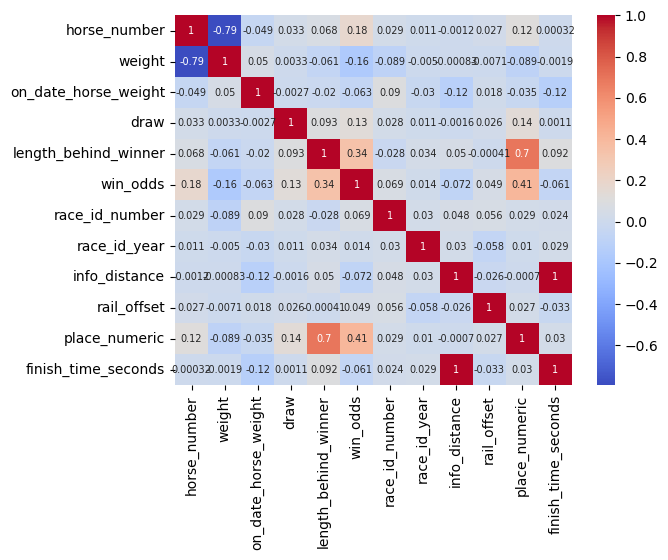

In [89]:
correlation = df[collection].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', annot_kws={"size": 7})
plt.show()

In [90]:
df.to_csv('HKHJ_Dataset_Prepared.csv', index=False)